In [26]:
import pytensor
# Tell PyTensor to use a more robust (but slower) backend that avoids C compilation issues.
# Place this in the first cell of your notebook.
# pytensor.config.optimizer = 'fast_compile'

import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib



## Get player details


In [27]:
# %run '../FPL predictors/Fantasy Go/map FGo to FPL.ipynb'

In [28]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
players_preds['efficiency'] = players_preds['xP_preds'] / players_preds['value']

# Filter to work with only a limited number of players with good xP_pred:value
eff_threshold = players_preds.groupby('position')['efficiency'].quantile(0.30)
filtered_players = players_preds[
    players_preds['efficiency'] >= players_preds['position'].map(eff_threshold)
]

optimizer_pool = filtered_players.copy()


fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

optimizer_pool = optimizer_pool.rename(columns={'FPL_Name': 'fpl_name', 'Understat_Name': 'understat_name'})
# Add fpl_id to player_preds
optimizer_pool = optimizer_pool.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
optimizer_pool.dropna(subset=['FPL_ID'], inplace=True)

optimizer_pool = optimizer_pool.drop(['event', 'understat_name', 'fpl_name', 'FPL_ID','FPL_Name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home', 'assists_x'], axis=1)
player_cols = optimizer_pool.columns.tolist()

In [29]:
common_features = [
    'expected_goals_conceded_rolling_5', 'influence_5_ewm', 'lose_prob', 'transfers_in_5_ewm', 'xA_5_ewm', 'percentage_net_transfers_5_ewm', 'xGBuildup_3_ewm',
    'xGBuildup_5_ewm', 'ict_index_rolling_5', 'assists_3_ewm', 'ownership_change_rolling_3', 'value', 'xP_5_ewm', 'selected_by_percent_5_ewm',
    'selected_by_percent_rolling_1', 'win_prob', 'influence_rolling_5', 'selected_by_percent', 'npg_3_ewm', 'minutes_rolling_5','selected_by_percent_rolling_5',
    'npxG_rolling_3', 'expected_goals_conceded_5_ewm', 'xGBuildup_rolling_3', 'transfers_in_rolling_1', 'value_rolling_5',
    'expected_goal_involvements_rolling_1', 'expected_goals_conceded_rolling_1', 'xGChain_rolling_1', 'ownership_change', 'influence_3_ewm', 'transfers_out',
    'xP_rolling_1', 'xP_3_ewm', 'selected_rolling_5', 'transfers_out_rolling_1', 'expected_goals_conceded_3_ewm', 'percentage_net_transfers_3_ewm',
    'xGChain_rolling_3', 'xGBuildup_rolling_5', 'xGChain_rolling_5', 'goals_conceded_5_ewm', 'xP_rolling_3', 'percentage_net_transfers', 'yellow_cards_5_ewm',
    'npxG_rolling_5', 'transfers_out_rolling_5', 'xGChain_5_ewm', 'yellow_cards_3_ewm', 'creativity_rolling_1', 'ict_index_rolling_3', 'transfers_in_rolling_3',
    'pts_bps_3_ewm', 'influence_rolling_1', 'xA_rolling_5', 'ownership_change_rolling_1', 'transfers_in', 'clean_sheets_3_ewm', 'selected',
    'expected_goals_conceded_rolling_3', 'pts_bps_rolling_3', 'draw_prob', 'xA_rolling_3', 'xGBuildup_rolling_1', 'ownership_change_3_ewm',
    'percentage_net_transfers_rolling_5', 'ict_index_rolling_1', 'ownership_change_rolling_5', 'clean_sheets_5_ewm', 'creativity_rolling_3',
    'percentage_net_transfers_rolling_3', 'transfers_out_5_ewm', 'transfers_in_3_ewm', 'creativity_rolling_5', 'transfers_in_rolling_5',
    'goals_conceded_3_ewm', 'pts_bps_rolling_1', 'percentage_net_transfers_rolling_1', 'influence_rolling_3', 'pts_bps_5_ewm', 'pts_bps_rolling_5',
    'team_a_difficulty', 'team_h_difficulty'
]

common_features_gk = [
    'expected_goals_conceded_rolling_5', 'influence_5_ewm', 'lose_prob', 'transfers_in_5_ewm', 'xA_5_ewm', 'percentage_net_transfers_5_ewm', 'xGBuildup_3_ewm',
    'xGBuildup_5_ewm', 'ict_index_rolling_5', 'assists_3_ewm', 'ownership_change_rolling_3', 'value', 'xP_5_ewm', 'selected_by_percent_5_ewm',
    'selected_by_percent_rolling_1', 'win_prob', 'influence_rolling_5', 'selected_by_percent', 'npg_3_ewm', 'minutes_rolling_5','selected_by_percent_rolling_5',
    'npxG_rolling_3', 'expected_goals_conceded_5_ewm', 'xGBuildup_rolling_3', 'transfers_in_rolling_1', 'value_rolling_5',
    'expected_goal_involvements_rolling_1', 'expected_goals_conceded_rolling_1', 'xGChain_rolling_1', 'ownership_change', 'influence_3_ewm', 'transfers_out',
    'xP_rolling_1', 'xP_3_ewm', 'selected_rolling_5', 'transfers_out_rolling_1', 'expected_goals_conceded_3_ewm', 'percentage_net_transfers_3_ewm',
    'xGChain_rolling_3', 'xGBuildup_rolling_5', 'xGChain_rolling_5', 'goals_conceded_5_ewm', 'xP_rolling_3', 'percentage_net_transfers', 'yellow_cards_5_ewm',
    'npxG_rolling_5', 'transfers_out_rolling_5', 'xGChain_5_ewm', 'yellow_cards_3_ewm', 'creativity_rolling_1', 'ict_index_rolling_3', 'transfers_in_rolling_3',
    'pts_bps_3_ewm', 'influence_rolling_1', 'xA_rolling_5', 'ownership_change_rolling_1', 'transfers_in', 'clean_sheets_3_ewm', 'selected',
    'expected_goals_conceded_rolling_3', 'pts_bps_rolling_3', 'draw_prob', 'xA_rolling_3', 'xGBuildup_rolling_1', 'ownership_change_3_ewm',
    'percentage_net_transfers_rolling_5', 'ict_index_rolling_1', 'ownership_change_rolling_5', 'clean_sheets_5_ewm', 'creativity_rolling_3',
    'percentage_net_transfers_rolling_3', 'transfers_out_5_ewm', 'transfers_in_3_ewm', 'creativity_rolling_5', 'transfers_in_rolling_5',
    'goals_conceded_3_ewm', 'pts_bps_rolling_1', 'percentage_net_transfers_rolling_1', 'influence_rolling_3', 'pts_bps_5_ewm', 'pts_bps_rolling_5',
    'team_a_difficulty', 'team_h_difficulty',
]

data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]

feats_cols = ["selected", "transfers_in", "transfers_out", "value", "xP_5", "total_points_1", "team_h_difficulty", "team_a_difficulty", "ownership_percent"]


feats_cols_gk = [
                'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
                'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
                'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
                'selected_by_percent_5_ewm','expected_goals_conceded_1_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_5_ewm',
                'clean_sheets_1_ewm', 'clean_sheets_5_ewm', 'saves_1_ewm', 'saves_5_ewm',
]

feats_cols_def = [
                'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
                'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
                'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
                'selected_by_percent_5_ewm','expected_goals_conceded_1_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_5_ewm',
                 'clean_sheets_1_ewm', 'clean_sheets_5_ewm', 'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]
feats_cols_mid = [
                'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
                'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
                'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
                'selected_by_percent_5_ewm', 'npxG_5_ewm', 'npxG_1_ewm',  'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]

feats_cols_fwd = [
                'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
                'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
                'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
                'selected_by_percent_5_ewm', 'npxG_5_ewm', 'npxG_1_ewm',  'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]

FPL_teams_23_24 = ['West Ham United', 'Manchester United', 'Everton', 'Bournemouth',
       'Brighton and Hove Albion', 'Crystal Palace', 'Fulham', 'Luton',
       'Tottenham Hotspur', 'Newcastle United', 'Aston Villa',
       'Liverpool', 'Chelsea', 'Sheffield United', 'Nottingham Forest',
       'Burnley', 'Arsenal', 'Manchester City', 'Wolverhampton Wanderers',
       'Brentford']

# data_23_24[feats_cols_rest]

In [30]:
gw=31
# data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv') #.dropna()
data_23_24 = pd.read_csv('./data_preds_23_24.csv')

data_23_24 = data_23_24[data_23_24['player_team'].isin(FPL_teams_23_24)]

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)

data_23_24[data_23_24['position'] == 'FWD']['xP'].max()

# players_preds = players_preds[players_preds['minutes_rolling_3']>35]
thresholds = {'GK':2 , 'DEF': 2, 'MID': 2, 'FWD': 3}

data_23_24 = data_23_24[
    data_23_24['xP'] > data_23_24['position'].map(thresholds)
]

data_23_24

,fpl_id,round,understat_id,player_team,FPL_Name,Understat_Name,position,team,opponent_team,fpl_name,...,selected_by_percent_3_ewm,selected_by_percent_5_ewm,ownership_change_1_ewm,ownership_change_3_ewm,ownership_change_5_ewm,percentage_net_transfers_1_ewm,percentage_net_transfers_3_ewm,percentage_net_transfers_5_ewm,xP_pred,xP_cost
2,2,27,22163.0,Arsenal,Cédric Alves Soares,Cédric Soares,DEF,Arsenal,Sheffield United,Cédric Alves Soares,...,0.001741,0.001729,-40285.0,-15077.875,-7443.000000,-0.004508,-0.001741,-0.000865,NaN,0.61
3,3,10,21986.0,Arsenal,Mohamed Elneny,Mohamed Elneny,MID,Arsenal,Sheffield United,Mohamed Elneny,...,0.000000,0.000000,0.0,0.000,0.000000,0.000000,0.000000,0.000000,NaN,0.52
6,4,3,22297.0,Arsenal,Fábio Ferreira Vieira,Fábio Vieira,MID,Arsenal,Fulham,Fábio Ferreira Vieira,...,0.000000,0.000000,0.0,0.000,0.000000,NaN,NaN,NaN,NaN,0.52
7,4,4,21934.0,Arsenal,Fábio Ferreira Vieira,Fábio Vieira,MID,Arsenal,Manchester United,Fábio Ferreira Vieira,...,0.000453,0.000302,9325.0,4662.500,3108.333333,0.000906,0.000906,0.000906,NaN,0.52
8,4,5,21941.0,Arsenal,Fábio Ferreira Vieira,Fábio Vieira,MID,Arsenal,Everton,Fábio Ferreira Vieira,...,0.000756,0.000555,2029.0,3345.750,2748.555556,0.000153,0.000530,0.000655,NaN,0.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11715,813,24,22131.0,Nottingham Forest,Fabian Mrozek,Fabian Schär,GK,Nottingham Forest,Newcastle United,Fabian Mrozek,...,0.000000,0.000000,0.0,0.000,0.000000,0.000000,0.000000,0.000000,NaN,0.52
11755,823,34,22232.0,Sheffield United,Oliver Arblaster,Oliver Arblaster,MID,Sheffield United,Burnley,Oliver Arblaster,...,0.000045,0.000037,213.0,130.625,101.417924,-0.000001,0.000007,0.000008,1.750064,0.56
11760,824,25,22151.0,Liverpool,Jayden Danns,Jayden Danns,FWD,Liverpool,Luton,Jayden Danns,...,0.000000,0.000000,0.0,0.000,0.000000,0.000000,0.000000,0.000000,NaN,0.89
11799,862,37,22260.0,Newcastle United,Tyrese Hall,Lewis Hall,MID,Newcastle United,Brighton and Hove Albion,Tyrese Hall,...,0.000000,0.000000,0.0,0.000,0.000000,0.000000,0.000000,0.000000,1.768396,0.71


In [31]:
data_tar = data_23_24[data_23_24['round']==gw]
data = data_23_24[data_23_24['round'] < gw]

data_24_25_test = data_23_24[data_23_24['round'] > gw]

joblib.dump(data_cols, './data_cols')

# data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][feats_cols_gk].copy() #[data_cols_gk]
def_data = data[data['position'] == 'DEF'][feats_cols_def].copy()#[data_cols]
mid_data = data[data['position'] == 'MID'][feats_cols_mid].copy()#[data_cols]
fwd_data = data[data['position'] == 'FWD'][feats_cols_fwd].copy()#[data_cols]

# transfers_in_log = np.log(df['transfers_in'] + 1)


# fwd_data
gk_data = gk_data.dropna()
def_data = def_data.dropna()
mid_data = mid_data.dropna()
fwd_data = fwd_data.dropna()


In [32]:
gk_data['transfers_in_log'] = gk_data['transfers_in'].apply(lambda x: np.log(x + 1))

gk_data['transfers_out_log'] = gk_data['transfers_out'].apply(lambda x: np.log(x + 1))
# gk_data['selected_log'] = gk_data['ownership_change'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
gk_data['saves_times_transfers'] = gk_data['saves_5_ewm'] * gk_data['transfers_in_log']
# points1_times_transfers = 'pts_bps_1 * transfers_in
gk_data['points1_times_transfers'] = gk_data['pts_bps_5_ewm'] * gk_data['transfers_in_log']
gk_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


# DEF data
def_data['transfers_in_log'] = def_data['transfers_in'].apply(lambda x: np.log(x + 1))
def_data['transfers_out_log'] = def_data['transfers_out'].apply(lambda x: np.log(x + 1))
# def_data['selected_log'] = def_data['ownership_change'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xA_5 * transfers_in
def_data['xa_times_transfers'] = def_data['xA_5_ewm'] * def_data['transfers_in_log']
# points1_times_transfers = 'pts_bps_1 * transfers_in
def_data['points1_times_transfers'] = def_data['pts_bps_5_ewm'] * def_data['transfers_in_log']
def_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


# MID data
mid_data['transfers_in_log'] = mid_data['transfers_in'].apply(lambda x: np.log(x + 1))
mid_data['transfers_out_log'] = mid_data['transfers_out'].apply(lambda x: np.log(x + 1))
# mid_data['selected_log'] = mid_data['ownership_change'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
mid_data['npxg_times_transfers'] = mid_data['npxG_5_ewm'] * mid_data['transfers_in_log']
# points1_times_transfers = pts_bps_5_ewm * transfers_in
mid_data['points1_times_transfers'] = mid_data['pts_bps_5_ewm'] * mid_data['transfers_in_log']
mid_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


# FWD data
fwd_data['transfers_in_log'] = fwd_data['transfers_in'].apply(lambda x: np.log(x + 1))

fwd_data['transfers_out_log'] = fwd_data['transfers_out'].apply(lambda x: np.log(x + 1))
# fwd_data['selected_log'] = fwd_data['ownership_change'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
fwd_data['npxg_times_transfers'] = fwd_data['npxG_5_ewm'] * fwd_data['transfers_in_log']
# points1_times_transfers = pts_bps_5_ewm * transfers_in
fwd_data['points1_times_transfers'] = fwd_data['pts_bps_5_ewm'] * fwd_data['transfers_in_log']
fwd_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

In [33]:
gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

# Selection percentages
gk_select_by = gk_data['selected_by_percent']
def_select_by = def_data['selected_by_percent']
mid_select_by = mid_data['selected_by_percent']
fwd_select_by = fwd_data['selected_by_percent']


# Normalise the select_percts to get the working probs
gk_probs = gk_select_by/np.sum(gk_select_by)
def_probs = def_select_by/np.sum(def_select_by)
mid_probs = mid_select_by/np.sum(mid_select_by)
fwd_probs = fwd_select_by/np.sum(fwd_select_by)

# 1. Define a small constant (epsilon) to replace the zeros
epsilon = 1e-9 # A very small number

# 2. Replace all zeros with this small number
gk_probs[gk_probs == 0] = epsilon
def_probs[def_probs == 0] = epsilon
mid_probs[mid_probs == 0] = epsilon
fwd_probs[fwd_probs == 0] = epsilon

gk_data = gk_data.drop(columns='selected_by_percent')
def_data = def_data.drop(columns='selected_by_percent')
mid_data = mid_data.drop(columns='selected_by_percent')
fwd_data = fwd_data.drop(columns='selected_by_percent')

In [34]:
# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

# print(gk_data.shape)
X_gk = pd.DataFrame(scaler_gk.fit_transform(gk_data.values), columns=gk_data.columns)
X_def = pd.DataFrame(scaler_def.fit_transform(def_data.values), columns=def_data.columns)
X_mid = pd.DataFrame(scaler_mid.fit_transform(mid_data.values), columns=mid_data.columns)
X_fwd = pd.DataFrame(scaler_fwd.fit_transform(fwd_data.values), columns=fwd_data.columns)

# save standardscaler model
joblib.dump(scaler_gk, "./betas/scaler_gk.pkl")
joblib.dump(scaler_def, "./betas/scaler_def.pkl")
joblib.dump(scaler_mid, "./betas/scaler_mid.pkl")
joblib.dump(scaler_fwd, "./betas/scaler_fwd.pkl")


['./betas/scaler_fwd.pkl']

## Generate Betas


In [35]:
def fit_dirichlet_regression(X, P_observed):
    """
    Fits a Bayesian Dirichlet regression model using PyMC to estimate beta coefficients.


    Args:
        X (np.ndarray): The feature matrix for a specific position (e.g., GKs).
                        Shape should be (num_players, num_features).
        P_observed (np.ndarray): The observed historical ownership proportions for that position.
                                 Shape should be (num_players,). Must sum to 1.

    Returns:
        pm.backends.base.MultiTrace: The results of the MCMC simulation, containing posterior samples for beta.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Define priors for our beta coefficients. We'll use a flat (uninformative) prior as mentioned.
        # [span_0](start_span)This corresponds to p(beta) in equation (6)[span_0](end_span).
        # betas = pm.Uniform("betas", lower=-5, upper=5, shape=(n_features,)) #
        betas = pm.Normal("betas", mu=0, sigma=1, shape=(n_features,))

        # 2. Calculate alpha based on the linear model: alpha = exp(X * beta)
        # [span_1](start_span)This is equation (4) in the paper[span_1](end_span).
        alpha = pm.math.exp(pm.math.dot(X, betas)) + 1e-6

        # 3. Define the likelihood of our observed data P_observed
        # The observed ownership proportions are assumed to follow a Dirichlet distribution
        # parameterized by alpha. [span_2](start_span)[span_3](start_span)This is the core of the regression[span_2](end_span)[span_3](end_span).
        pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 4. Run the MCMC sampler to get the posterior distribution of beta
        print("Fitting Dirichlet regression model with PyMC...")
        trace = pm.sample(3000, tune=1000, chains=4, cores=4)
        print("✅ Model fitting complete.")

        # approx = pm.fit(n=2000, method='advi', progressbar=True)
        # trace = approx.sample(2000)

    return trace

In [36]:
def fit_regularized_dirichlet_regression(X, P_observed, sparsity_strength=0.1):
    """
    Fits a Bayesian Dirichlet regression model with Laplace (Lasso) regularization.

    Args:
        X (np.ndarray): Feature matrix (num_players, num_features).
        P_observed (np.ndarray): Observed ownership proportions (sums to 1).
        sparsity_strength (float): Lower values (e.g., 0.1) force more coefficients to zero.
                                   Higher values (e.g., 1.0) allow more features to stay active.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Sparsity Control
        # We use a fixed small value here to force the 'Lasso' effect.
        # If you want it learned, use: b = pm.HalfNormal("b", sigma=sparsity_strength)
        # b = sparsity_strength
        b = pm.HalfNormal("b", sigma=sparsity_strength)

        # 2. Regularized Priors for Betas
        # Laplace distribution is the key for Lasso regularization.
        betas = pm.Laplace("betas", mu=0, b=b, shape=(n_features,))

        # 3. Calculate Alpha (Concentration Parameters)
        # alpha = exp(X * beta)
        lin_pred = pm.math.dot(X, betas)
        alpha = pm.math.exp(lin_pred) + 1e-6

        # 4. Dirichlet Likelihood
        pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 5. MCMC Sampling
        print(f"Fitting Regularized Dirichlet model (Sparsity Strength: {sparsity_strength})...")
        trace = pm.sample(
            draws=2000,
            tune=3000,
            chains=4,
            cores=4,
            target_accept=0.99,
            init="adapt_full",
            random_seed=42
        )
        print("✅ Regularized model fitting complete.")

    return trace

### GK


Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 502 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.04,0.06,-0.07,0.16,0.0,0.0,7101.95,5759.21,1.0
betas[1],0.01,0.06,-0.10,0.14,0.0,0.0,7061.90,5044.25,1.0
betas[2],-0.05,0.06,-0.17,0.06,0.0,0.0,8065.26,5207.63,1.0
betas[3],0.08,0.05,-0.01,0.17,0.0,0.0,7908.10,5758.93,1.0
betas[4],0.02,0.04,-0.05,0.11,0.0,0.0,8380.47,5780.14,1.0
betas[5],0.04,0.04,-0.04,0.12,0.0,0.0,7802.12,5886.16,1.0
betas[6],-0.01,0.06,-0.13,0.12,0.0,0.0,7115.33,4884.57,1.0
betas[7],-0.03,0.08,-0.19,0.12,0.0,0.0,7093.53,4165.13,1.0
betas[8],-0.02,0.05,-0.13,0.08,0.0,0.0,7801.53,5095.15,1.0
betas[9],0.03,0.06,-0.08,0.15,0.0,0.0,7157.59,5000.19,1.0


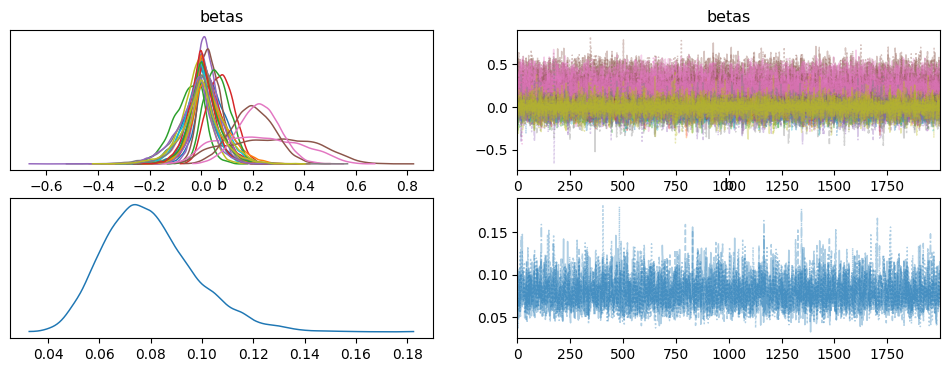

In [177]:
# Fit the model to get beta estimates
trace_gk = fit_regularized_dirichlet_regression(X_gk, gk_probs)

# trace_gk
az.plot_trace(trace_gk, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_gk = az.summary(trace_gk, var_names=["betas"], round_to=2)
summary_gk

In [180]:
signal_mask_gk = get_dynamic_feature_mask(trace_gk)
masked_summary_gk = summary_gk[signal_mask_gk]
masked_summary_gk

masked_feats_gk = X_gk.iloc[:, signal_mask_gk]
masked_feats_gk.columns


Pruning complete: Removed 27 noise features. 2 signals remain.


Index(['transfers_in_log', 'transfers_out_log'], dtype='object')

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 55 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.29,0.06,0.18,0.41,0.0,0.0,6558.40,5296.21,1.0
betas[1],0.54,0.07,0.41,0.66,0.0,0.0,5539.04,4568.50,1.0


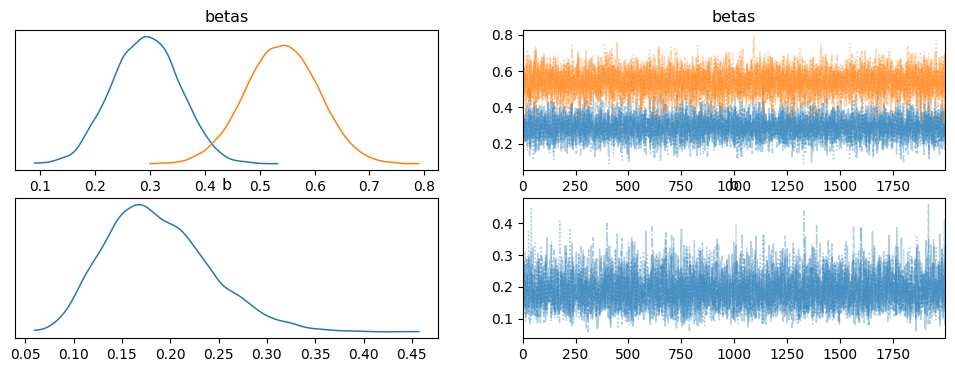

In [181]:
# Fit the model to get beta estimates
trace_gk_2 = fit_regularized_dirichlet_regression(masked_feats_gk, gk_probs)

# trace_gk
az.plot_trace(trace_gk_2, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_gk_2 = az.summary(trace_gk_2, var_names=["betas"], round_to=2)
summary_gk_2

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 67 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.29,0.06,0.18,0.41,0.0,0.0,6558.40,5296.21,1.0
betas[1],0.54,0.07,0.41,0.66,0.0,0.0,5539.04,4568.50,1.0


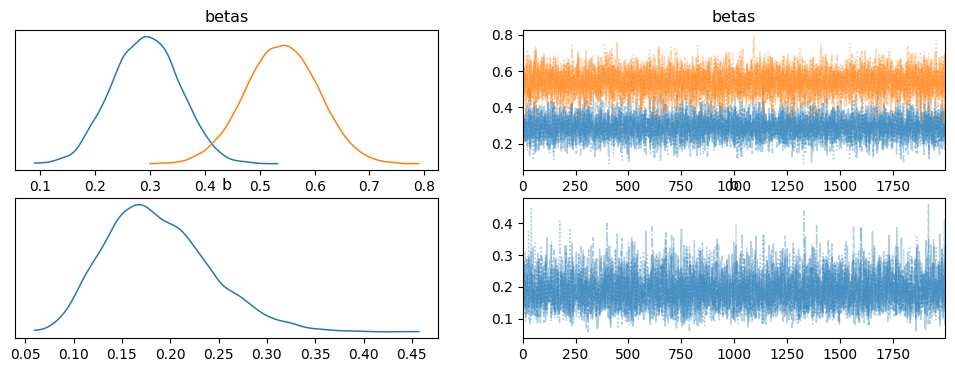

In [183]:
X_gk_cleaned_2 = masked_feats_gk[[
    'transfers_in_log', 'transfers_out_log'
]]

# Fit the model to get beta estimates
trace_gk_3 = fit_regularized_dirichlet_regression(X_gk_cleaned_2, gk_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_gk = trace_gk_3.posterior['betas'].mean(axis=(0,1)).values

# trace_gk_3
az.plot_trace(trace_gk_3, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_gk = az.summary(trace_gk_3, var_names=["betas"], round_to=2)
summary_gk

### DEF


Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 946 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.00,0.04,-0.06,0.07,0.0,0.0,14874.90,5500.79,1.0
betas[1],0.00,0.04,-0.08,0.08,0.0,0.0,13835.32,5232.02,1.0
betas[2],0.02,0.03,-0.03,0.08,0.0,0.0,14056.93,5496.59,1.0
betas[3],0.08,0.03,0.03,0.13,0.0,0.0,17579.27,5771.44,1.0
betas[4],0.06,0.02,0.02,0.11,0.0,0.0,14915.12,6157.84,1.0
betas[5],0.05,0.02,0.00,0.09,0.0,0.0,16467.05,6371.35,1.0
betas[6],-0.01,0.04,-0.09,0.06,0.0,0.0,12918.67,5323.16,1.0
betas[7],-0.02,0.06,-0.15,0.09,0.0,0.0,12094.26,5151.33,1.0
betas[8],-0.06,0.04,-0.13,0.01,0.0,0.0,16970.92,6149.35,1.0
betas[9],0.03,0.04,-0.05,0.11,0.0,0.0,16693.05,5607.98,1.0


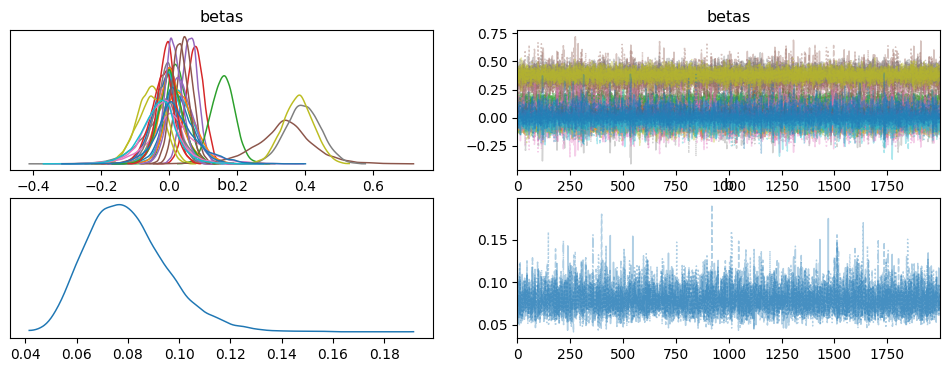

In [176]:
# Fit the model to get beta estimates
trace_def = fit_regularized_dirichlet_regression(X_def, def_probs)

# trace_def
az.plot_trace(trace_def, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_def = az.summary(trace_def, var_names=["betas"], hdi_prob=0.94, round_to=2)
summary_def

In [184]:
signal_mask_def = get_dynamic_feature_mask(trace_def)
masked_summary_def = summary_def[signal_mask_def]
masked_summary_def

masked_feats_def = X_def.iloc[:, signal_mask_def]
masked_feats_def.columns


Pruning complete: Removed 24 noise features. 7 signals remain.


Index(['value', 'team_h_difficulty', 'team_a_difficulty',
       'percentage_net_transfers', 'selected_by_percent_1_ewm',
       'transfers_in_log', 'transfers_out_log'],
      dtype='object')

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 128 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.05,0.02,0.01,0.09,0.0,0.0,11649.69,6182.52,1.0
betas[1],0.08,0.02,0.04,0.12,0.0,0.0,11501.67,6000.16,1.0
betas[2],0.07,0.02,0.03,0.11,0.0,0.0,10486.91,6248.63,1.0
betas[3],0.14,0.01,0.12,0.16,0.0,0.0,11836.04,5382.55,1.0
betas[4],0.35,0.02,0.32,0.39,0.0,0.0,11643.89,6462.93,1.0
betas[5],0.40,0.04,0.33,0.46,0.0,0.0,11208.03,6091.53,1.0
betas[6],0.40,0.04,0.32,0.47,0.0,0.0,11522.27,5751.51,1.0


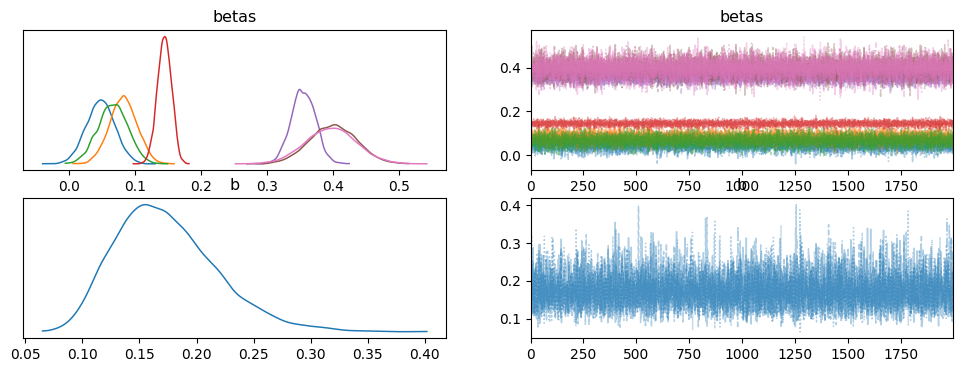

In [185]:
# Fit the model to get beta estimates
trace_def_2 = fit_regularized_dirichlet_regression(masked_feats_def, def_probs)

# trace_def
az.plot_trace(trace_def_2, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_def_2 = az.summary(trace_def_2, var_names=["betas"], round_to=2)
summary_def_2

In [187]:
masked_feats_def.columns

Index(['value', 'team_h_difficulty', 'team_a_difficulty',
       'percentage_net_transfers', 'selected_by_percent_1_ewm',
       'transfers_in_log', 'transfers_out_log'],
      dtype='object')

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 97 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.06,0.02,0.02,0.10,0.0,0.0,9942.27,5181.77,1.0
betas[1],0.17,0.01,0.15,0.19,0.0,0.0,10596.87,5951.75,1.0
betas[2],0.42,0.02,0.39,0.46,0.0,0.0,10752.70,5562.80,1.0
betas[3],0.55,0.03,0.49,0.60,0.0,0.0,10896.88,4629.44,1.0


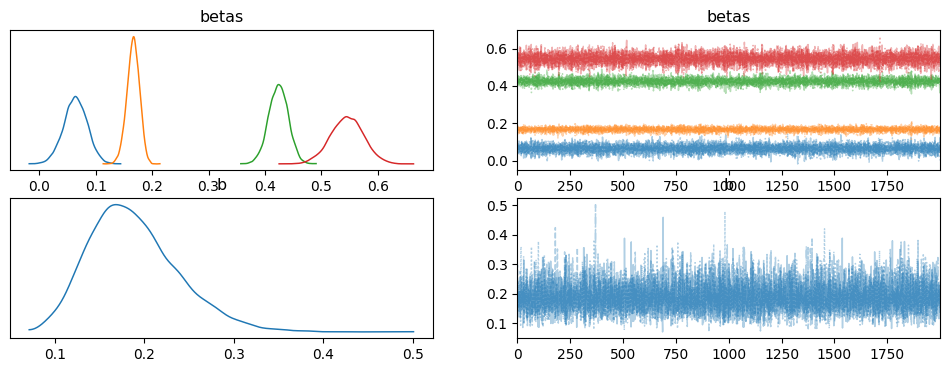

In [188]:
X_def_cleaned_2 = masked_feats_def[[
    'value', 'percentage_net_transfers', 'selected_by_percent_1_ewm', 'transfers_in_log'
]]

# Fit the model to get beta estimates
trace_def_3 = fit_regularized_dirichlet_regression(X_def_cleaned_2, def_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_def = trace_def_3.posterior['betas'].mean(axis=(0,1)).values

# trace_def_3
az.plot_trace(trace_def_3, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_def = az.summary(trace_def_3, var_names=["betas"], round_to=2)
summary_def

### MID


Initializing NUTS using adapt_full...


Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 585 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.05,0.02,0.01,0.09,0.0,0.0,15375.19,5645.22,1.0
betas[1],-0.00,0.02,-0.05,0.04,0.0,0.0,15341.17,5414.77,1.0
betas[2],0.05,0.02,0.01,0.08,0.0,0.0,13675.73,6387.58,1.0
betas[3],0.13,0.01,0.10,0.16,0.0,0.0,16014.85,6000.88,1.0
betas[4],0.02,0.01,-0.01,0.04,0.0,0.0,15250.37,6330.18,1.0
betas[5],0.03,0.02,-0.01,0.05,0.0,0.0,14377.97,5929.97,1.0
betas[6],0.00,0.02,-0.05,0.05,0.0,0.0,15424.24,5871.49,1.0
betas[7],-0.15,0.10,-0.35,0.03,0.0,0.0,12222.77,6107.82,1.0
betas[8],-0.06,0.02,-0.11,-0.02,0.0,0.0,15854.19,5791.11,1.0
betas[9],0.02,0.03,-0.04,0.09,0.0,0.0,15819.24,5650.33,1.0


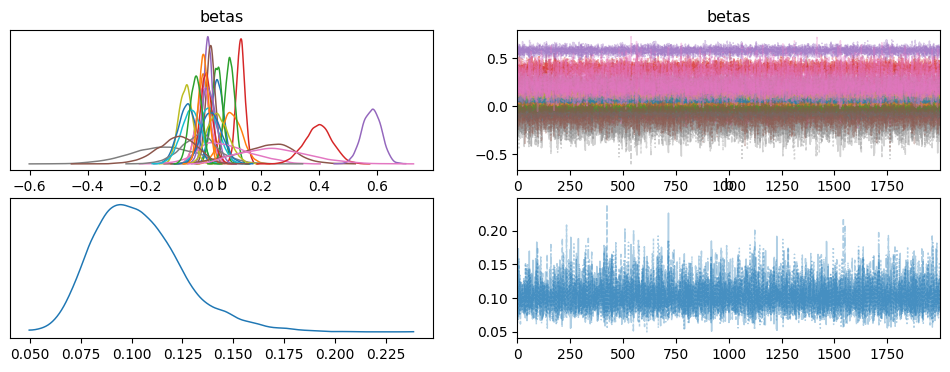

In [178]:
# Fit the model to get beta estimates
trace_mid = fit_regularized_dirichlet_regression(X_mid, mid_probs)

# trace_mid
az.plot_trace(trace_mid, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_mid = az.summary(trace_mid, var_names=["betas"], round_to=2)
summary_mid

In [ ]:
def get_dynamic_feature_mask(trace, hdi_prob=0.94):
    """
    Dynamically identifies noise features by checking if their HDI contains zero.

    Returns:
        mask (np.ndarray): Boolean array where True = Signal, False = Noise.
    """
    # Calculate the High Density Interval for all betas
    summary = az.summary(trace, var_names=["betas"], hdi_prob=hdi_prob)

    # A feature is 'Signal' if its HDI does NOT contain zersignal_mask_fwdo.
    # We check if (hdi_low > 0) OR (hdi_high < 0)
    # hdi_low = summary[f'hdi_3%'].values
    # hdi_high = summary[f'hdi_97%'].values

    hdi_low = summary[f'hdi_{int((1-hdi_prob)/2*100)}%'].values
    hdi_high = summary[f'hdi_{int((1+hdi_prob)/2*100+0.5)}%'].values

    signal_mask = (hdi_low > 0) | (hdi_high < 0)

    removed_count = len(signal_mask) - np.sum(signal_mask)
    print(f"Pruning complete: Removed {removed_count} noise features. {np.sum(signal_mask)} signals remain.")

    return signal_mask

In [189]:
signal_mask_mid = get_dynamic_feature_mask(trace_mid)
masked_summary_mid = summary_mid[signal_mask_mid]
masked_summary_mid

masked_feats_mid = X_mid.iloc[:, signal_mask_mid]
masked_feats_mid.columns


Pruning complete: Removed 17 noise features. 10 signals remain.


Index(['ownership_change', 'ownership_change_5_ewm', 'value', 'xP_1_ewm',
       'minutes_5_ewm', 'percentage_net_transfers',
       'selected_by_percent_1_ewm', 'transfers_in_log', 'transfers_out_log',
       'points1_times_transfers'],
      dtype='object')

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 149 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.05,0.02,0.01,0.09,0.0,0.0,9170.43,5700.26,1.0
betas[1],0.06,0.01,0.03,0.08,0.0,0.0,9577.50,6183.82,1.0
betas[2],0.14,0.01,0.11,0.16,0.0,0.0,10535.62,5934.37,1.0
betas[3],-0.06,0.02,-0.09,-0.02,0.0,0.0,8836.13,6439.47,1.0
betas[4],0.04,0.02,-0.00,0.08,0.0,0.0,10831.18,6255.13,1.0
betas[5],0.10,0.02,0.07,0.13,0.0,0.0,8350.74,6252.93,1.0
betas[6],0.28,0.01,0.26,0.30,0.0,0.0,9551.07,6243.24,1.0
betas[7],0.39,0.03,0.33,0.46,0.0,0.0,9923.51,6313.66,1.0
betas[8],0.61,0.03,0.55,0.65,0.0,0.0,9920.26,6127.13,1.0
betas[9],0.05,0.02,0.01,0.10,0.0,0.0,9539.81,6342.85,1.0


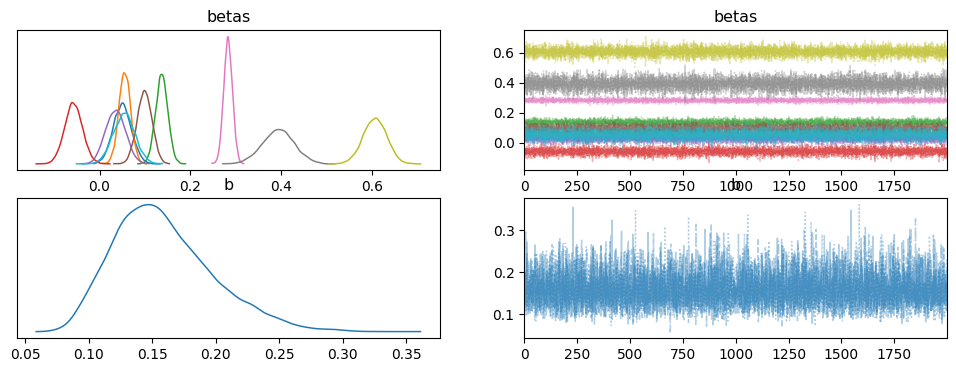

In [190]:
# Fit the model to get beta estimates
trace_mid_2 = fit_regularized_dirichlet_regression(masked_feats_mid, mid_probs)

# trace_mid
az.plot_trace(trace_mid_2, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_mid_2 = az.summary(trace_mid_2, var_names=["betas"], round_to=2)
summary_mid_2

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 101 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.19,0.01,0.17,0.22,0.0,0.0,10731.15,5846.82,1.0
betas[1],-0.12,0.02,-0.15,-0.09,0.0,0.0,9755.33,5278.83,1.0
betas[2],0.25,0.01,0.23,0.27,0.0,0.0,11438.53,5657.48,1.0
betas[3],0.72,0.02,0.68,0.76,0.0,0.0,10824.12,5657.19,1.0
betas[4],0.30,0.02,0.27,0.34,0.0,0.0,10499.52,6160.15,1.0


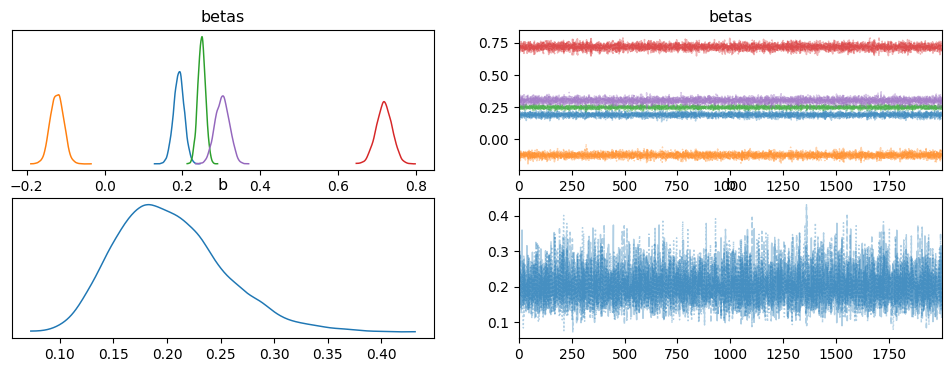

In [191]:
X_mid_cleaned_2 = masked_feats_mid[[
    'value', 'xP_1_ewm', 'selected_by_percent_1_ewm', 'transfers_out_log', 'points1_times_transfers'
]]

# Fit the model to get beta estimates
trace_mid_3 = fit_regularized_dirichlet_regression(X_mid_cleaned_2, mid_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_mid = trace_mid_3.posterior['betas'].mean(axis=(0,1)).values

# trace_mid_3
az.plot_trace(trace_mid_3, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_mid = az.summary(trace_mid_3, var_names=["betas"], round_to=2)
summary_mid

### FWD


Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 433 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.05,0.07,-0.08,0.19,0.0,0.0,11033.75,5976.93,1.0
betas[1],0.02,0.07,-0.11,0.16,0.0,0.0,10207.26,5208.00,1.0
betas[2],0.05,0.05,-0.04,0.14,0.0,0.0,10270.10,5676.26,1.0
betas[3],-0.02,0.05,-0.12,0.08,0.0,0.0,10498.26,5534.86,1.0
betas[4],0.02,0.04,-0.05,0.09,0.0,0.0,12091.81,5584.77,1.0
betas[5],0.02,0.04,-0.05,0.10,0.0,0.0,11344.27,5852.60,1.0
betas[6],-0.02,0.05,-0.12,0.07,0.0,0.0,10471.95,5312.46,1.0
betas[7],-0.03,0.09,-0.20,0.14,0.0,0.0,9274.09,5233.50,1.0
betas[8],-0.04,0.05,-0.14,0.05,0.0,0.0,11110.56,5883.61,1.0
betas[9],0.06,0.07,-0.07,0.19,0.0,0.0,10440.65,5662.02,1.0


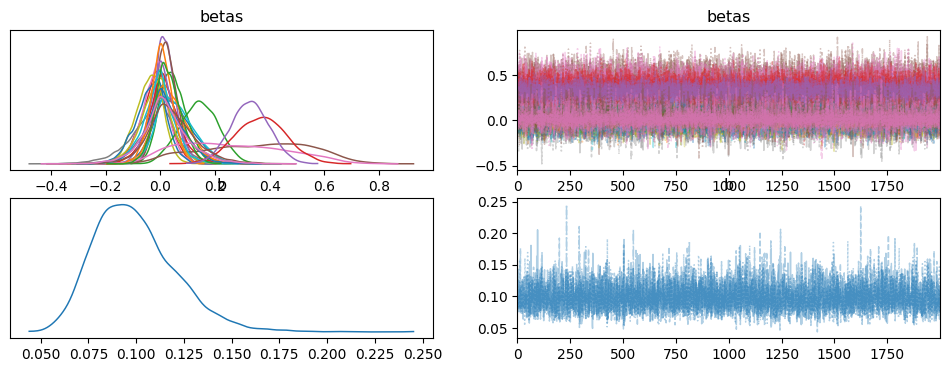

In [179]:
# Fit the model to get beta estimates
trace_fwd = fit_regularized_dirichlet_regression(X_fwd, fwd_probs)

# trace_fwd
az.plot_trace(trace_fwd, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_fwd = az.summary(trace_fwd, var_names=["betas"], round_to=2)
summary_fwd

In [192]:
signal_mask_fwd= get_dynamic_feature_mask(trace_fwd)
masked_summary_fwd= summary_fwd[signal_mask_fwd]
masked_summary_fwd

masked_feats_fwd= X_fwd.iloc[:, signal_mask_fwd]
masked_feats_fwd.columns


Pruning complete: Removed 24 noise features. 3 signals remain.


Index(['percentage_net_transfers', 'transfers_in_log', 'transfers_out_log'], dtype='object')

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 44 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.09,0.02,0.05,0.13,0.0,0.0,7599.70,4463.11,1.0
betas[1],0.36,0.06,0.25,0.48,0.0,0.0,8093.72,5585.23,1.0
betas[2],0.62,0.06,0.50,0.72,0.0,0.0,8821.13,5382.14,1.0


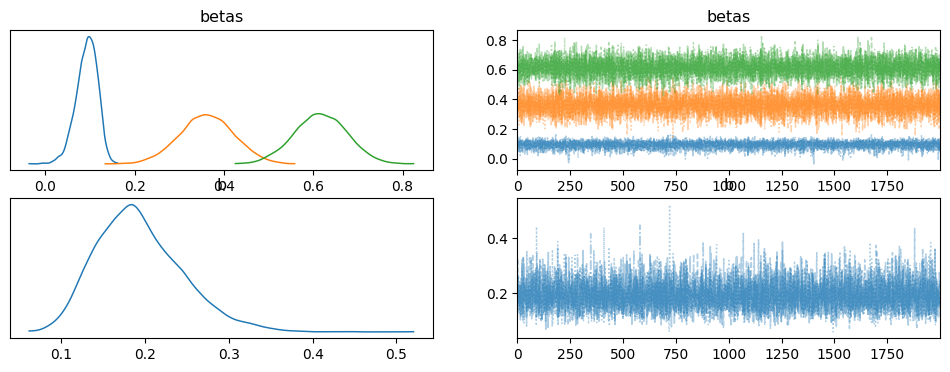

In [193]:
# Fit the model to get beta estimates
trace_fwd_2 = fit_regularized_dirichlet_regression(masked_feats_fwd, fwd_probs)

# trace_fwd
az.plot_trace(trace_fwd_2, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_fwd_2 = az.summary(trace_fwd_2, var_names=["betas"], round_to=2)
summary_fwd_2

Fitting Regularized Dirichlet model (Sparsity Strength: 0.1)...


Initializing NUTS using adapt_full...
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, betas]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 42 seconds.


✅ Regularized model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.09,0.02,0.05,0.13,0.0,0.0,7599.70,4463.11,1.0
betas[1],0.36,0.06,0.25,0.48,0.0,0.0,8093.72,5585.23,1.0
betas[2],0.62,0.06,0.50,0.72,0.0,0.0,8821.13,5382.14,1.0


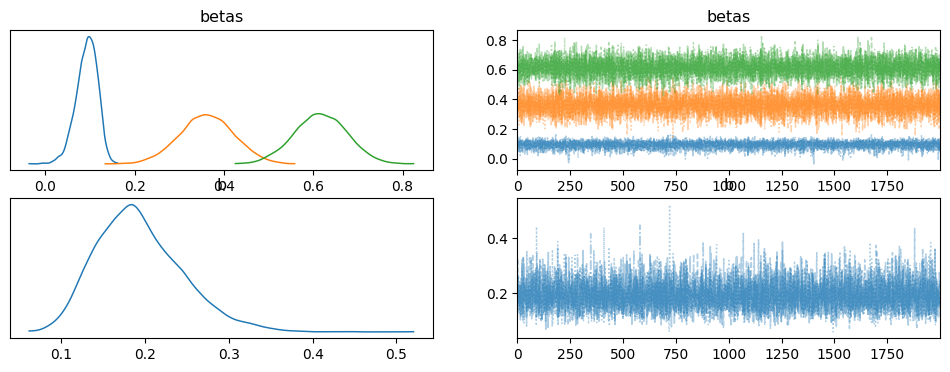

In [194]:
X_fwd_cleaned_2 = masked_feats_fwd[['percentage_net_transfers', 'transfers_in_log', 'transfers_out_log']]

# Fit the model to get beta estimates
trace_fwd_3 = fit_regularized_dirichlet_regression(X_fwd_cleaned_2, fwd_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_fwd = trace_fwd_3.posterior['betas'].mean(axis=(0,1)).values

# trace_fwd_3
az.plot_trace(trace_fwd_3, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary_fwd = az.summary(trace_fwd_3, var_names=["betas"], round_to=2)
summary_fwd

## Save


In [197]:
joblib.dump(trace_gk_3, './betas/trace_gk')
joblib.dump(trace_def_3, './betas/trace_def')
joblib.dump(trace_mid_3, './betas/trace_mid')
joblib.dump(trace_fwd_3, './betas/trace_fwd')

gk_feats = ['transfers_in_log', 'transfers_out_log']
def_feats = ['value', 'percentage_net_transfers', 'selected_by_percent_1_ewm', 'transfers_in_log']
mid_feats = ['value', 'xP_1_ewm', 'selected_by_percent_1_ewm', 'transfers_out_log', 'points1_times_transfers']
fwd_feats = ['percentage_net_transfers', 'transfers_in_log', 'transfers_out_log']

In [196]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_estimates_gk
}).to_csv('./betas/gk_betas.csv', index=False)

pd.DataFrame({
    "def": beta_estimates_def
}).to_csv('./betas/def_betas.csv', index=False)

pd.DataFrame({
    "mid": beta_estimates_mid
}).to_csv('./betas/mid_betas.csv', index=False)

pd.DataFrame({
    "fwd": beta_estimates_fwd
}).to_csv('./betas/fwd_betas.csv', index=False)